<a href="https://colab.research.google.com/github/RickV777/ENGAGEMENT_YT/blob/main/YouTube_TFT_Objetivo3_AnalisisFactorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Notebook 3 — Análisis Factorial Exploratorio (AFE)
### Tesis: Análisis de los Factores Determinantes del Engagement en YouTube
**Objetivo 3:** Identificar mediante AFE los factores latentes que agrupan las variables del dataset y explican el engagement.

---
**Flujo del notebook:**
1. Instalación de librerías
2. Carga del dataset procesado
3. Selección y estandarización de variables
4. Análisis de adecuación muestral (KMO + Bartlett)
5. Determinación del número de factores (Scree Plot + Regla Kaiser)
6. Extracción de factores (PCA + FA con rotación Varimax)
7. Interpretación de la matriz de cargas
8. Construcción de puntuaciones factoriales
9. Relación factores ↔ engagement (correlaciones + regresión)
10. Exportación de resultados

## Sección 1 — Instalación de librerías

In [1]:
# Instalar librerías necesarias
!pip install factor_analyzer pingouin -q

print("✅ Instalación completada")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.6 MB/s eta 0:00:00
✅ Instalación completada


## Sección 2 — Carga del dataset procesado

> Usa la opción que corresponda según dónde guardaste el CSV del NB1.

In [4]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import pingouin as pg

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

# ─── OPCIÓN B: CSV desde Google Drive (recomendado entre sesiones) ───
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/youtube_dataset_procesado.csv'

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

Mounted at /content/drive
✅ Dataset cargado: 528,663 filas × 26 columnas
Columnas: ['video_id', 'country', 'publishedAt', 'trending_date', 'publish_hour', 'publish_dayofweek', 'publish_dayname', 'publish_month', 'publish_year', 'franja_horaria', 'dias_hasta_trending', 'category_name', 'title_length', 'num_tags', 'rango_tags', 'rango_titulo', 'comments_disabled', 'ratings_disabled', 'view_count', 'likes', 'comment_count', 'log_views', 'log_likes', 'log_comments', 'engagement_rate', 'log_engagement']


## Sección 3 — Selección y preparación de variables para el AFE

El AFE requiere variables **numéricas continuas**. Seleccionamos las métricas cuantitativas disponibles en el dataset.

In [5]:
# Variables numéricas de interés para el AFE
VARS_AFE = [
    'view_count',
    'likes',
    'dislikes',
    'comment_count',
    'engagement_rate',
    'tags_count',
    'title_length',
    'days_to_trend',      # días entre publicación y que entró en trending
    'hour_published',
    'day_of_week'
]

# Verificar cuáles existen en el dataframe
vars_existentes = [v for v in VARS_AFE if v in df.columns]
vars_faltantes  = [v for v in VARS_AFE if v not in df.columns]

print(f"Variables disponibles ({len(vars_existentes)}): {vars_existentes}")
if vars_faltantes:
    print(f"⚠️  Variables a calcular: {vars_faltantes}")

Variables disponibles (5): ['view_count', 'likes', 'comment_count', 'engagement_rate', 'title_length']
⚠️  Variables a calcular: ['dislikes', 'tags_count', 'days_to_trend', 'hour_published', 'day_of_week']


In [7]:
# ─── Calcular variables que puedan faltar ───

# days_to_trend: diferencia entre trending_date y publishedAt
if 'days_to_trend' not in df.columns:
    df['publishedAt']    = pd.to_datetime(df['publishedAt'],    errors='coerce', utc=True)
    df['trending_date']  = pd.to_datetime(df['trending_date'],  errors='coerce', utc=True)
    df['days_to_trend']  = (df['trending_date'] - df['publishedAt']).dt.days.clip(lower=0)

# tags_count: número de tags
if 'tags_count' not in df.columns:
    if 'num_tags' in df.columns:
        df['tags_count'] = df['num_tags'] # Usar 'num_tags' si existe, asumiendo que ya es el conteo
    else:
        print("⚠️ Advertencia: Ni 'tags' ni 'num_tags' están disponibles para calcular 'tags_count'. 'tags_count' se omitirá.")

# title_length: longitud del título
if 'title_length' not in df.columns:
    df['title_length'] = df['title'].fillna('').apply(len)

# hour_published
if 'hour_published' not in df.columns and 'publishedAt' in df.columns:
    df['publishedAt'] = pd.to_datetime(df['publishedAt'], errors='coerce', utc=True)
    df['hour_published'] = df['publishedAt'].dt.hour

# day_of_week
if 'day_of_week' not in df.columns and 'publishedAt' in df.columns:
    df['day_of_week'] = df['publishedAt'].dt.dayofweek  # 0=Lun, 6=Dom

# Re-verificar
VARS_AFE_FINAL = [v for v in VARS_AFE if v in df.columns]
print(f"Variables finales para AFE: {VARS_AFE_FINAL}")

Variables finales para AFE: ['view_count', 'likes', 'comment_count', 'engagement_rate', 'tags_count', 'title_length', 'days_to_trend', 'hour_published', 'day_of_week']


In [8]:
# Crear subconjunto limpio para el AFE
df_afe = df[VARS_AFE_FINAL].copy()

# Eliminar infinitos y valores extremos (winsorización al 99.5%)
for col in VARS_AFE_FINAL:
    df_afe[col] = pd.to_numeric(df_afe[col], errors='coerce')
    upper = df_afe[col].quantile(0.995)
    lower = df_afe[col].quantile(0.005)
    df_afe[col] = df_afe[col].clip(lower=lower, upper=upper)

df_afe.dropna(inplace=True)

# Transformación logarítmica para variables con alta asimetría
vars_log = ['view_count', 'likes', 'dislikes', 'comment_count']
for col in vars_log:
    if col in df_afe.columns:
        df_afe[f'log_{col}'] = np.log1p(df_afe[col])

# Variables definitivas (usar log para las asimétricas)
VARS_MODELO = []
for col in VARS_AFE_FINAL:
    if col in vars_log:
        VARS_MODELO.append(f'log_{col}')
    else:
        VARS_MODELO.append(col)

VARS_MODELO = [v for v in VARS_MODELO if v in df_afe.columns]
print(f"Variables del modelo AFE: {VARS_MODELO}")
print(f"Registros para AFE: {len(df_afe):,}")

# Estandarización Z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_afe[VARS_MODELO])
df_scaled = pd.DataFrame(X_scaled, columns=VARS_MODELO)

print("\n✅ Datos estandarizados correctamente")
print(df_scaled.describe().round(3))

Variables del modelo AFE: ['log_view_count', 'log_likes', 'log_comment_count', 'engagement_rate', 'tags_count', 'title_length', 'days_to_trend', 'hour_published', 'day_of_week']
Registros para AFE: 528,663

✅ Datos estandarizados correctamente
       log_view_count   log_likes  log_comment_count  engagement_rate  \
count     528663.0000 528663.0000        528663.0000      528663.0000   
mean          -0.0000     -0.0000            -0.0000          -0.0000   
std            1.0000      1.0000             1.0000           1.0000   
min           -2.2340     -6.4350            -4.4720          -1.3630   
25%           -0.7020     -0.5310            -0.4900          -0.7360   
50%           -0.0950      0.0110             0.0150          -0.1840   
75%            0.6130      0.5890             0.5570           0.4590   
max            3.2280      2.5570             2.6190           4.3670   

       tags_count  title_length  days_to_trend  hour_published  day_of_week  
count 528663.0000   

## Sección 4 — Análisis de adecuación muestral

### 4.1 Prueba KMO (Kaiser-Meyer-Olkin)
Mide si la correlación entre variables es suficiente para el AFE.
- KMO ≥ 0.90 → Excelente | ≥ 0.80 → Buena | ≥ 0.70 → Aceptable | < 0.60 → Inadecuado

### 4.2 Prueba de esfericidad de Bartlett
H₀: La matriz de correlaciones es una matriz identidad (no hay correlación entre variables).
Si p < 0.05 → rechazamos H₀ → las variables están suficientemente correlacionadas.

In [9]:
# ─── KMO ───
kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"KMO General: {kmo_model:.4f}")
print(f"KMO por variable:")
for var, val in zip(VARS_MODELO, kmo_all):
    estado = "✅" if val >= 0.7 else ("⚠️" if val >= 0.5 else "❌")
    print(f"  {estado} {var:<25}: {val:.4f}")

# Interpretación KMO
if kmo_model >= 0.90:
    kmo_interp = "Excelente"
elif kmo_model >= 0.80:
    kmo_interp = "Buena"
elif kmo_model >= 0.70:
    kmo_interp = "Aceptable"
elif kmo_model >= 0.60:
    kmo_interp = "Mediocre"
else:
    kmo_interp = "Inadecuada — considera eliminar variables con KMO < 0.5"

print(f"\n→ Adecuación muestral: {kmo_interp}")

# ─── Bartlett ───
chi2, p_bartlett = calculate_bartlett_sphericity(df_scaled)
print(f"\nBartlett Chi²: {chi2:.2f},  p = {p_bartlett:.2e}")
if p_bartlett < 0.05:
    print("✅ p < 0.05 → Las variables están correlacionadas. Se puede proceder con el AFE.")
else:
    print("❌ p ≥ 0.05 → No hay correlación suficiente. El AFE no es apropiado.")

KMO General: 0.5530
KMO por variable:
  ❌ log_view_count           : 0.4874
  ⚠️ log_likes                : 0.5795
  ✅ log_comment_count        : 0.7911
  ❌ engagement_rate          : 0.3338
  ⚠️ tags_count               : 0.5365
  ✅ title_length             : 0.7692
  ⚠️ days_to_trend            : 0.6801
  ❌ hour_published           : 0.4847
  ⚠️ day_of_week              : 0.6736

→ Adecuación muestral: Inadecuada — considera eliminar variables con KMO < 0.5

Bartlett Chi²: 1174391.63,  p = 0.00e+00
✅ p < 0.05 → Las variables están correlacionadas. Se puede proceder con el AFE.


## Sección 5 — Determinación del número de factores

In [10]:
# ─── PCA para Scree Plot y Regla de Kaiser ───
pca = PCA()
pca.fit(df_scaled)

eigenvalues = pca.explained_variance_
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

# Número de factores según Kaiser (eigenvalue > 1)
n_kaiser = np.sum(eigenvalues > 1)
print(f"Factores con eigenvalue > 1 (Regla de Kaiser): {n_kaiser}")

# Tabla de eigenvalues
print("\n Nº  | Eigenvalue | % Var | % Acumulado")
print("-" * 45)
for i, (ev, pvar, pcum) in enumerate(zip(eigenvalues, pca.explained_variance_ratio_*100, cum_var), 1):
    marca = " ← Kaiser" if ev > 1 else ""
    print(f"  {i:2d} | {ev:10.4f} | {pvar:5.2f}% | {pcum:6.2f}%{marca}")
    if i >= 10:
        print("  ...")
        break

Factores con eigenvalue > 1 (Regla de Kaiser): 4

 Nº  | Eigenvalue | % Var | % Acumulado
---------------------------------------------
   1 |     2.5264 | 28.07% |  28.07% ← Kaiser
   2 |     1.3633 | 15.15% |  43.22% ← Kaiser
   3 |     1.0970 | 12.19% |  55.41% ← Kaiser
   4 |     1.0459 | 11.62% |  67.03% ← Kaiser
   5 |     0.9728 | 10.81% |  77.84%
   6 |     0.7745 |  8.61% |  86.44%
   7 |     0.7097 |  7.89% |  94.33%
   8 |     0.3727 |  4.14% |  98.47%
   9 |     0.1377 |  1.53% | 100.00%


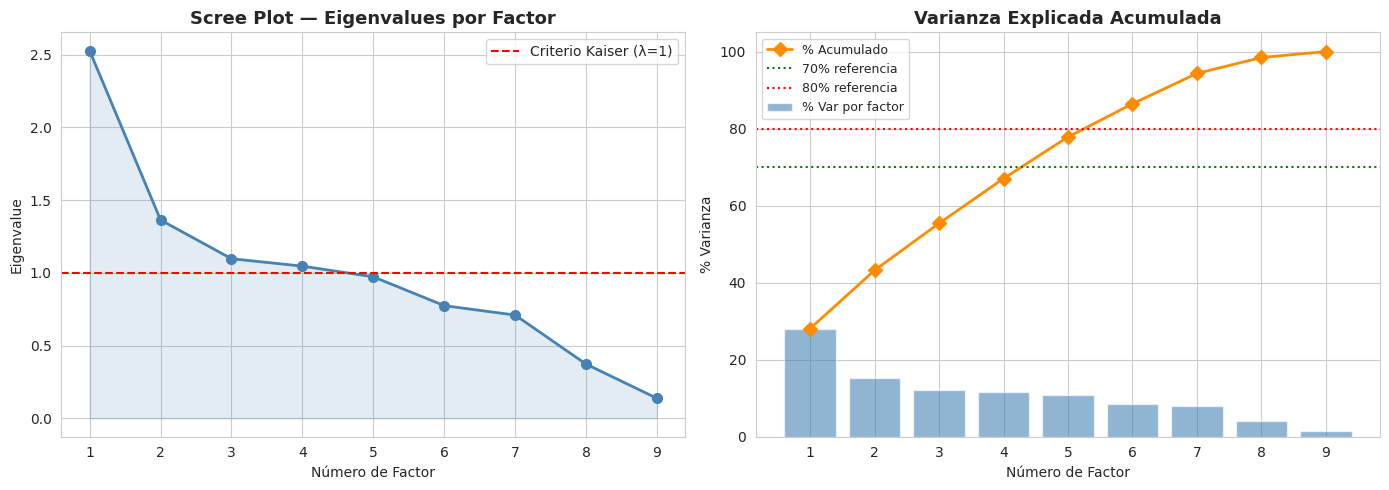


→ Número de factores sugerido (Kaiser): 4


In [11]:
# ─── Scree Plot ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(15, len(eigenvalues))
x = range(1, n_show + 1)

# Scree Plot
axes[0].plot(x, eigenvalues[:n_show], 'o-', color='steelblue', lw=2, markersize=7)
axes[0].axhline(y=1, color='red', linestyle='--', lw=1.5, label='Criterio Kaiser (λ=1)')
axes[0].fill_between(x, eigenvalues[:n_show], alpha=0.15, color='steelblue')
axes[0].set_title('Scree Plot — Eigenvalues por Factor', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Factor')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()
axes[0].set_xticks(list(x))

# Varianza acumulada
axes[1].bar(x, pca.explained_variance_ratio_[:n_show]*100, color='steelblue', alpha=0.6, label='% Var por factor')
axes[1].plot(x, cum_var[:n_show], 'D-', color='darkorange', lw=2, markersize=7, label='% Acumulado')
axes[1].axhline(y=70, color='green', linestyle=':', lw=1.5, label='70% referencia')
axes[1].axhline(y=80, color='red', linestyle=':', lw=1.5, label='80% referencia')
axes[1].set_title('Varianza Explicada Acumulada', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Factor')
axes[1].set_ylabel('% Varianza')
axes[1].legend(fontsize=9)
axes[1].set_xticks(list(x))

plt.tight_layout()
plt.savefig('/content/nb3_fig1_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n→ Número de factores sugerido (Kaiser): {n_kaiser}")

## Sección 6 — Extracción de Factores con Rotación Varimax

Usamos **Análisis Factorial Exploratorio** con el método de mínimo residuo (minres) y rotación **Varimax** (ortogonal), que maximiza la varianza de las cargas al cuadrado para facilitar la interpretación.

In [13]:
# Número de factores (ajustar si necesitas más/menos)
N_FACTORES = n_kaiser if n_kaiser >= 2 else 3

fa = FactorAnalyzer(n_factors=N_FACTORES, rotation='varimax', method='minres')
fa.fit(df_scaled)

# Cargas factoriales
loadings = pd.DataFrame(
    fa.loadings_,
    index=VARS_MODELO,
    columns=[f'Factor_{i+1}' for i in range(N_FACTORES)]
)

# Comunalidades
communalities = pd.Series(fa.get_communalities(), index=VARS_MODELO, name='Comunalidad')

# Varianza explicada
# fa.get_factor_variance() retorna (eigenvalues, variance_ratio, cumulative_variance_ratio)
ev, var_ratio, cum_var_ratio = fa.get_factor_variance()
var_df = pd.DataFrame({
    'Eigenvalue':      ev,
    'Varianza_%':      var_ratio * 100,
    'Var_Acumulada_%': cum_var_ratio * 100
}, index=[f'Factor_{i+1}' for i in range(N_FACTORES)])

print("=" * 70)
print("VARIANZA EXPLICADA POR FACTOR")
print("=" * 70)
print(var_df.round(4))
print(f"\nVarianza total explicada: {var_df['Varianza_%'].sum():.2f}%")
print("\n" + "=" * 70)
print("COMUNALIDADES (h²) — varianza de cada variable explicada por los factores")
print("=" * 70)
print(communalities.round(4).to_string())

VARIANZA EXPLICADA POR FACTOR
          Eigenvalue  Varianza_%  Var_Acumulada_%
Factor_1      2.1887     24.3185          24.3185
Factor_2      1.0109     11.2318          35.5502
Factor_3      0.9971     11.0789          46.6291
Factor_4      0.3886      4.3176          50.9467

Varianza total explicada: 50.95%

COMUNALIDADES (h²) — varianza de cada variable explicada por los factores
log_view_count      0.9791
log_likes           0.8074
log_comment_count   0.5410
engagement_rate     0.7915
tags_count          0.1670
title_length        0.1925
days_to_trend       0.1076
hour_published      0.9950
day_of_week         0.0040


In [14]:
# ─── Matriz de Cargas Factoriales ───
print("=" * 70)
print("MATRIZ DE CARGAS FACTORIALES (rotación Varimax)")
print("Cargas ≥ |0.40| se consideran significativas")
print("=" * 70)

# Resaltar cargas significativas
loadings_display = loadings.copy()
for col in loadings_display.columns:
    loadings_display[col] = loadings_display[col].apply(
        lambda x: f"{x:.4f} *" if abs(x) >= 0.40 else f"{x:.4f}  "
    )
print(loadings_display.to_string())

MATRIZ DE CARGAS FACTORIALES (rotación Varimax)
Cargas ≥ |0.40| se consideran significativas
                    Factor_1   Factor_2   Factor_3   Factor_4
log_view_count      0.7132 *  -0.1274     0.6725 *   0.0439  
log_likes           0.8798 *  -0.0094     0.1232    -0.1345  
log_comment_count   0.7260 *  -0.0389     0.0853     0.0714  
engagement_rate     0.5572 *   0.0945    -0.6363 *  -0.2593  
tags_count          0.0882     0.0267    -0.0248     0.3974  
title_length       -0.2263    -0.0432     0.0494     0.3701  
days_to_trend       0.0694     0.0405     0.3170    -0.0244  
hour_published      0.0608     0.9890 *   0.1122    -0.0264  
day_of_week         0.0274    -0.0428     0.0374    -0.0055  


## Sección 7 — Visualización de la Matriz de Cargas

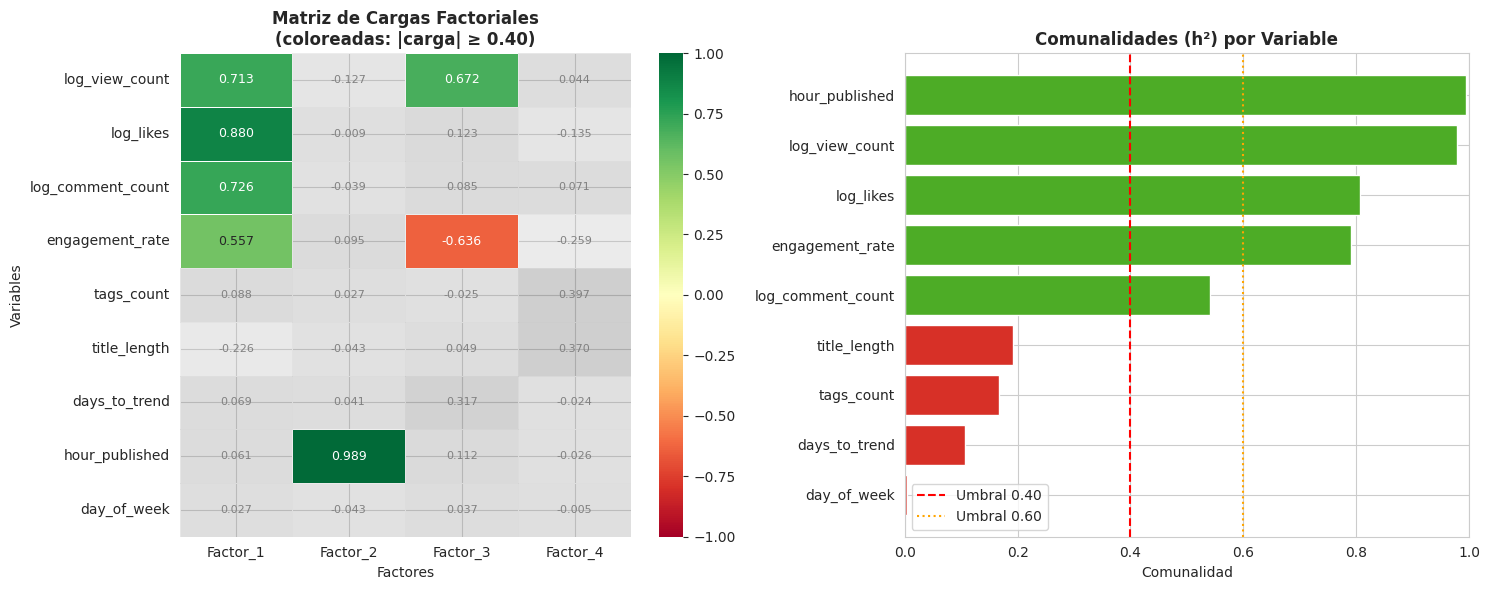

In [15]:
# ─── Heatmap de Cargas Factoriales ───
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
mask_insig = np.abs(loadings.values) < 0.40
sns.heatmap(
    loadings,
    annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0],
    mask=mask_insig, annot_kws={'size': 9}
)
# Mostrar insig en gris
sns.heatmap(
    loadings,
    annot=True, fmt='.3f', cmap='Greys',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0],
    mask=~mask_insig, annot_kws={'size': 8, 'color': 'grey'},
    alpha=0.3, cbar=False
)
axes[0].set_title('Matriz de Cargas Factoriales\n(coloreadas: |carga| ≥ 0.40)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Factores')
axes[0].set_ylabel('Variables')

# Comunalidades
comm_sorted = communalities.sort_values(ascending=True)
colors = ['#d73027' if v < 0.40 else '#4dac26' for v in comm_sorted]
axes[1].barh(comm_sorted.index, comm_sorted.values, color=colors, edgecolor='white')
axes[1].axvline(x=0.40, color='red', linestyle='--', lw=1.5, label='Umbral 0.40')
axes[1].axvline(x=0.60, color='orange', linestyle=':', lw=1.5, label='Umbral 0.60')
axes[1].set_title('Comunalidades (h²) por Variable', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Comunalidad')
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/content/nb3_fig2_cargas_comunalidades.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 8 — Interpretación y Denominación de Factores

Con base en las cargas significativas (|carga| ≥ 0.40), identifica qué variables agrupan cada factor y asígnale un nombre teórico.

In [16]:
# ─── Identificar variables dominantes por factor ───
UMBRAL = 0.40

print("VARIABLES DOMINANTES POR FACTOR (|carga| ≥ 0.40)")
print("=" * 60)
factor_labels = {}  # Llenar manualmente según interpretación

for factor in loadings.columns:
    dominantes = loadings[factor][np.abs(loadings[factor]) >= UMBRAL].sort_values(ascending=False, key=abs)
    print(f"\n{factor}:")
    for var, carga in dominantes.items():
        signo = "+" if carga > 0 else "-"
        print(f"  {signo} {var:<30}: {carga:.4f}")

print("\n" + "=" * 60)
print("💡 GUÍA PARA NOMBRAR LOS FACTORES:")
print("  - Si agrupa likes, comments, views → 'Factor de Popularidad/Alcance'")
print("  - Si agrupa hour, day_of_week → 'Factor Temporal de Publicación'")
print("  - Si agrupa tags_count, title_length → 'Factor de Optimización de Contenido'")
print("  - Si agrupa engagement_rate → 'Factor de Engagement Relativo'")

VARIABLES DOMINANTES POR FACTOR (|carga| ≥ 0.40)

Factor_1:
  + log_likes                     : 0.8798
  + log_comment_count             : 0.7260
  + log_view_count                : 0.7132
  + engagement_rate               : 0.5572

Factor_2:
  + hour_published                : 0.9890

Factor_3:
  + log_view_count                : 0.6725
  - engagement_rate               : -0.6363

Factor_4:

💡 GUÍA PARA NOMBRAR LOS FACTORES:
  - Si agrupa likes, comments, views → 'Factor de Popularidad/Alcance'
  - Si agrupa hour, day_of_week → 'Factor Temporal de Publicación'
  - Si agrupa tags_count, title_length → 'Factor de Optimización de Contenido'
  - Si agrupa engagement_rate → 'Factor de Engagement Relativo'


In [17]:
# ─── Renombrar factores (ajusta según tu interpretación) ───
NOMBRES_FACTORES = {
    'Factor_1': 'F1_Popularidad',
    'Factor_2': 'F2_Temporalidad',
    'Factor_3': 'F3_Optimizacion',
}
# Añade más si n_kaiser > 3

loadings_named = loadings.rename(columns={
    k: v for k, v in NOMBRES_FACTORES.items()
    if k in loadings.columns
})

print("Factores renombrados:")
print(loadings_named.round(4))

Factores renombrados:
                   F1_Popularidad  F2_Temporalidad  F3_Optimizacion  Factor_4
log_view_count             0.7132          -0.1274           0.6725    0.0439
log_likes                  0.8798          -0.0094           0.1232   -0.1345
log_comment_count          0.7260          -0.0389           0.0853    0.0714
engagement_rate            0.5572           0.0945          -0.6363   -0.2593
tags_count                 0.0882           0.0267          -0.0248    0.3974
title_length              -0.2263          -0.0432           0.0494    0.3701
days_to_trend              0.0694           0.0405           0.3170   -0.0244
hour_published             0.0608           0.9890           0.1122   -0.0264
day_of_week                0.0274          -0.0428           0.0374   -0.0055


## Sección 9 — Puntuaciones Factoriales y Relación con Engagement

In [18]:
# ─── Obtener puntuaciones factoriales ───
factor_scores = pd.DataFrame(
    fa.transform(df_scaled),
    columns=[f'Factor_{i+1}' for i in range(N_FACTORES)]
)

# Agregar engagement al dataframe de scores
factor_scores['engagement_rate'] = df_afe['engagement_rate'].values
factor_scores['pais'] = df.loc[df_afe.index, 'pais'].values if 'pais' in df.columns else 'N/D'

print(f"Puntuaciones factoriales generadas: {factor_scores.shape}")
print(factor_scores.describe().round(4))

Puntuaciones factoriales generadas: (528663, 6)
         Factor_1    Factor_2    Factor_3    Factor_4  engagement_rate
count 528663.0000 528663.0000 528663.0000 528663.0000      528663.0000
mean      -0.0000      0.0000      0.0000      0.0000           0.0611
std        0.9539      0.9967      0.9336      0.5684           0.0439
min       -4.1851     -2.3607     -4.1991     -2.7826           0.0013
25%       -0.6228     -1.0307     -0.5825     -0.4056           0.0288
50%       -0.0575      0.3138      0.0061     -0.0028           0.0531
75%        0.5733      0.7976      0.5855      0.3909           0.0813
max        3.9156      1.6011      5.5714      2.9471           0.2529


In [19]:
# ─── Correlación factores ↔ engagement ───
print("CORRELACIONES SPEARMAN: Factores ↔ Engagement Rate")
print("=" * 55)

factor_cols = [f'Factor_{i+1}' for i in range(N_FACTORES)]
for fc in factor_cols:
    r, p = spearmanr(factor_scores[fc], factor_scores['engagement_rate'])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    print(f"  {fc}: r = {r:.4f}, p = {p:.4f}  {sig}")

CORRELACIONES SPEARMAN: Factores ↔ Engagement Rate
  Factor_1: r = 0.5519, p = 0.0000  ***
  Factor_2: r = 0.1326, p = 0.0000  ***
  Factor_3: r = -0.6510, p = 0.0000  ***
  Factor_4: r = -0.4693, p = 0.0000  ***


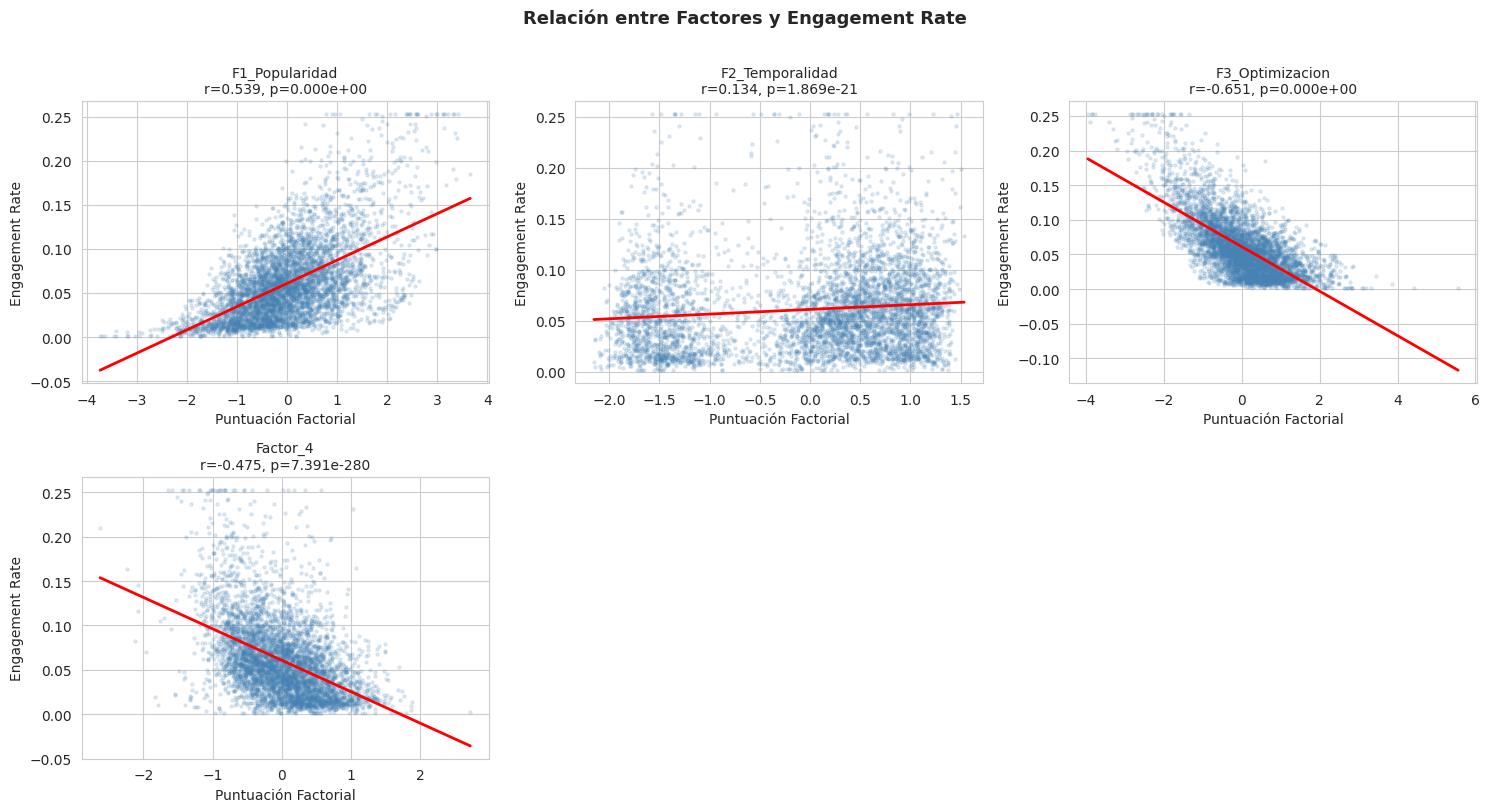

In [20]:
# ─── Gráfico: Scatter factores vs engagement ───
factor_cols = [f'Factor_{i+1}' for i in range(N_FACTORES)]
ncols = min(N_FACTORES, 3)
nrows = (N_FACTORES + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

sample = factor_scores.sample(min(5000, len(factor_scores)), random_state=42)

for i, fc in enumerate(factor_cols):
    axes[i].scatter(sample[fc], sample['engagement_rate'],
                    alpha=0.15, s=5, color='steelblue')
    z = np.polyfit(sample[fc], sample['engagement_rate'], 1)
    p_line = np.poly1d(z)
    xline = np.linspace(sample[fc].min(), sample[fc].max(), 100)
    axes[i].plot(xline, p_line(xline), 'r-', lw=2)

    r, pval = spearmanr(sample[fc], sample['engagement_rate'])
    nombre = NOMBRES_FACTORES.get(fc, fc)
    axes[i].set_title(f'{nombre}\nr={r:.3f}, p={pval:.3e}', fontsize=10)
    axes[i].set_xlabel('Puntuación Factorial')
    axes[i].set_ylabel('Engagement Rate')

# Ocultar ejes sobrantes
for j in range(N_FACTORES, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación entre Factores y Engagement Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/nb3_fig3_factores_vs_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ─── Regresión múltiple: Factores → Engagement ───
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pingouin as pg

X_reg = factor_scores[factor_cols].values
y_reg = factor_scores['engagement_rate'].values

reg = LinearRegression()
reg.fit(X_reg, y_reg)
y_pred = reg.predict(X_reg)
r2 = r2_score(y_reg, y_pred)

print("REGRESIÓN LINEAL MÚLTIPLE: Factores → Engagement Rate")
print("=" * 55)
print(f"R² = {r2:.4f}  ({r2*100:.2f}% de la varianza explicada)")
print(f"Intercepto: {reg.intercept_:.6f}")
print("\nCoeficientes:")
for fc, coef in zip(factor_cols, reg.coef_):
    print(f"  {fc}: β = {coef:.6f}")

REGRESIÓN LINEAL MÚLTIPLE: Factores → Engagement Rate
R² = 0.9339  (93.39% de la varianza explicada)
Intercepto: 0.061136

Coeficientes:
  Factor_1: β = 0.028811
  Factor_2: β = 0.004356
  Factor_3: β = -0.033022
  Factor_4: β = -0.013630


## Sección 10 — Exportación de resultados

In [22]:
# ─── Guardar todos los artefactos ───
import os

# 1. Matriz de cargas
loadings.round(4).to_csv('/content/nb3_cargas_factoriales.csv')

# 2. Comunalidades
communalities.round(4).to_frame().to_csv('/content/nb3_comunalidades.csv')

# 3. Varianza por factor
var_df.round(4).to_csv('/content/nb3_varianza_factores.csv')

# 4. Puntuaciones factoriales (muestra)
factor_scores.to_csv('/content/nb3_puntuaciones_factoriales.csv', index=False)

# 5. KMO + Bartlett en tabla
resumen_adecuacion = pd.DataFrame({
    'Prueba': ['KMO General', 'Bartlett Chi²', 'Bartlett p-value'],
    'Valor':  [f'{kmo_model:.4f}', f'{chi2:.2f}', f'{p_bartlett:.2e}'],
    'Interpretación': [kmo_interp, 'Esfericidad del factor', 'p < 0.05 → AFE válido']
})
resumen_adecuacion.to_csv('/content/nb3_kmo_bartlett.csv', index=False)

print("✅ Archivos exportados en /content/:")
for f in os.listdir('/content/'):
    if f.startswith('nb3_'):
        size = os.path.getsize(f'/content/{f}')
        print(f"  📄 {f} ({size/1024:.1f} KB)")

✅ Archivos exportados en /content/:
  📄 nb3_comunalidades.csv (0.2 KB)
  📄 nb3_cargas_factoriales.csv (0.4 KB)
  📄 nb3_fig2_cargas_comunalidades.png (161.9 KB)
  📄 nb3_fig1_scree_plot.png (100.8 KB)
  📄 nb3_kmo_bartlett.csv (0.2 KB)
  📄 nb3_fig3_factores_vs_engagement.png (554.6 KB)
  📄 nb3_varianza_factores.csv (0.2 KB)
  📄 nb3_puntuaciones_factoriales.csv (52439.6 KB)


In [24]:
# ─── Guardar en Google Drive ───

from google.colab import drive
drive.mount('/content/drive')
import shutil, os
archivos_nb3 = [f for f in os.listdir('/content/') if f.startswith('nb3_')]
for archivo in archivos_nb3:
    shutil.copy(f'/content/{archivo}', f'/content/drive/MyDrive/{archivo}')
    print(f'Guardado: {archivo}')
print(" Todos los archivos del NB3 guardados en Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Guardado: nb3_comunalidades.csv
Guardado: nb3_cargas_factoriales.csv
Guardado: nb3_fig2_cargas_comunalidades.png
Guardado: nb3_fig1_scree_plot.png
Guardado: nb3_kmo_bartlett.csv
Guardado: nb3_fig3_factores_vs_engagement.png
Guardado: nb3_varianza_factores.csv
Guardado: nb3_puntuaciones_factoriales.csv
 Todos los archivos del NB3 guardados en Google Drive
